In [55]:
from langgraph.graph import START, END, StateGraph, add_messages
from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langchain_core.runnables import Runnable
from typing import Literal, Annotated
from collections.abc import Sequence

In [56]:
from dotenv import load_dotenv
load_dotenv()

True

In [57]:
my_list = add_messages([HumanMessage("Hii! I am ANIK."),
                                     AIMessage("Hey, Anik. How Can I Help You?")],
                                     [HumanMessage("Please Summarise recent news")])

my_list

[HumanMessage(content='Hii! I am ANIK.', additional_kwargs={}, response_metadata={}, id='dc5dedaf-582a-4093-9b21-0a44d09cd859'),
 AIMessage(content='Hey, Anik. How Can I Help You?', additional_kwargs={}, response_metadata={}, id='7c335dc6-6362-4cb2-a8d0-b18a2c8e5013', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Please Summarise recent news', additional_kwargs={}, response_metadata={}, id='ab43c607-9666-4945-af0e-ce8a15062b56')]

In [58]:
class State(TypedDict):
    messages : Annotated[Sequence[BaseMessage], add_messages]

#add_message is a reducer function that defines how to combine the current state with the new incomming data in a structured way 

In [59]:
def ask(state=State)-> State:
    print("\n-------> Entering the ask state")
    for i in state['messages']:
        i.pretty_print()
    question = "What is your Question ?"
    print(question)

    return State(messages=[AIMessage(question), HumanMessage(input())])    

In [60]:
chat = ChatGroq(
    model="qwen/qwen3.6-27b",
    #max_output_tokens=1000,
    temperature=0,
    seed=42
)

c:\Users\ANIK CHOWDHURY\Desktop\AI_Updated\.venv\Lib\site-packages\pydantic\main.py:263: UserWarning: WARNING! seed is not default parameter.
                    seed was transferred to model_kwargs.
                    Please confirm that seed is what you intended.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)


In [61]:
def chatbot(state:State)-> State:
    print("\n--------------> Entering Chatbot:")
    response = chat.invoke(state['messages'])
    response.pretty_print()
    return State(messages = [response])

In [62]:
def ask_another(state=State)->State:
    print("\n --------------> Entering Ask Another State:")
    for i in state['messages']:
        i.pretty_print()
    question = "Any other question ? (Yes/No)"
    print(question)

    return State(messages=[AIMessage(content=question), HumanMessage(content=input().strip())])

In [63]:
def routing(state:State)-> Literal["ask", "__end__"]:
    if state["messages"][-1].content.lower() == "yes":
        return "ask"
    else:
        return "__end__"

In [64]:
graph = StateGraph(State)

graph.add_node('ask', ask)
graph.add_node('chatbot', chatbot)
graph.add_node('ask_another', ask_another)

In [65]:
graph.add_edge(START, "ask")
graph.add_edge("ask", "chatbot")
graph.add_edge("chatbot", "ask_another")
graph.add_conditional_edges(source='ask_another', path = routing)



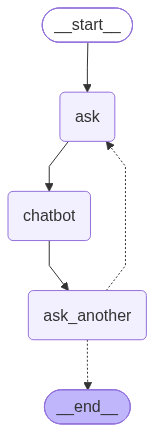

In [66]:
graph_complied = graph.compile()

graph_complied

In [68]:
graph_complied.invoke(State(messages=[]))


-------> Entering the ask state
What is your Question ?

--------------> Entering Chatbot:
================================== Ai Message ==================================


<think>
Here's a thinking process:

1.  **Identify the User's Question**: The user is asking "who is the cm of west bengal" (Chief Minister of West Bengal, India).

2.  **Determine the Current Information**: I need to recall or verify the current Chief Minister of West Bengal as of my last training data (2024). 
   - Mamata Banerjee has been the Chief Minister of West Bengal since 2011.
   - She won the 2021 West Bengal Legislative Assembly election and was sworn in for her fourth consecutive term in May 2021.
   - As of 2024, she is still the CM.

3.  **Check for Recent Changes**: I should consider if there have been any recent elections or changes. The next West Bengal assembly election is scheduled for 2026. No major changes have occurred between 2021 and 2024.

4.  **Formulate the Response**: 
   - State clear

{'messages': [AIMessage(content='What is your Question ?', additional_kwargs={}, response_metadata={}, id='6a1ff550-470f-4156-aef7-534a70128ff3', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='who is the cm of west bengal', additional_kwargs={}, response_metadata={}, id='6e64a7bd-7bb1-4377-b5ac-73f8021104b3'),
  AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Identify the User\'s Question**: The user is asking "who is the cm of west bengal" (Chief Minister of West Bengal, India).\n\n2.  **Determine the Current Information**: I need to recall or verify the current Chief Minister of West Bengal as of my last training data (2024). \n   - Mamata Banerjee has been the Chief Minister of West Bengal since 2011.\n   - She won the 2021 West Bengal Legislative Assembly election and was sworn in for her fourth consecutive term in May 2021.\n   - As of 2024, she is still the CM.\n\n3.  **Check for Recent Changes**: I should consider if there have been any recent 